----
# Laboratorium 6 - Układy stabilne i minimalnofazowe
----
Materiały dydaktyczne przeznaczone są wyłącznie dla studentów Wydziału Informatyki i Telekomunikacji Politechniki Poznańskiej 

----
## 0. Zagadnienia do opanowania przed zajęciami
----

* badanie stabilności układu (stabilność w sensie BIBO) 
* analiza układów zamkniętych pętlą sprzężenia zwrotnego
* analiza układów minimalnofazowych
* zera i bieguny transmitancji  

Funkcje z biblioteki *scipy.signal* potrzebne do zrealizowania ćwiczenia:  
`scipy.signal.freqresp`, `scipy.signal.signal.tf2ss`,  `scipy.signal.impulse`

Dokumentacja i opisy poszczególnych funkcji *scipy.signal*:  
https://docs.scipy.org/doc/scipy/reference/signal.html    



In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal
poles_figsize  =(8, 8)
default_figsize=(14, 8)

---- 
## 1. Pojęcie stabilności
---- 
* Co to znaczy że układ jest stabilny?
* Jakie są kryteria stabilności?
* Jak sprawdzić czy układ jest stabilny?

---- 
## 2. Zbadaj stabilność w sensie BIBO
---- 
| | |
|------------------------------------------|------------------------------------|
|$$H(s) = {{s^2-2s+3} \over {s^2+2s+ 1}}$$  |  $$H(s) = {{s^2+1}\over{s^2+3s+1}}$$|
|$$ H(s) = {{1} \over {s^2 + 2}} $$  |$$ H(s) = {{1} \over {s^2 +8s+15}} $$|
|$$ H(s) = {{s^2-2s+3} \over {s^2 + 2}} $$  |$$ H(s) = {{1} \over {s^2 +6s-7}} $$|
|$$ H(s) = {{s + 2} \over {s + 1}} $$  |$$ H(s) = {{1} \over {s+1}} $$|
|$$ H(s) = {{s - 1} \over {s + 1}} $$|$$ H(s) = {{1} \over {s-1}} $$|
|$$ H(s) = {{2s+3} \over {s^2 + 4s + 4}} $$|$$ H(s) = {{s+1} \over {s+ 2}} $$|
|$$ H(s) = {{s^4+2s^3+2s^2+2} \over {s^3-2s^2 + 4s + 1}} $$|$$ H(s) = {{s-1} \over {s+ 2}} $$|
W tym celu zdefiniuj wektor złożony ze współczynników przy każdej zmiennej s do stopnia danego wielomianu. Wykorzystaj funkcję np.poly1d oraz np.roots. Uwaga, jeśli dla układu definiujemy transmitancję jako współczynniki licznika i mianownika (num, den), to współczynniki powinny być podane w kolejności malejącego wykładnika (np. s^2 + 3s + 5 byłyby reprezentowane jako [1, 3, 5]). W miejsce R i C podstaw wartości jednostkowe. Przedstaw położenie biegunów na płąszczyźnie zespolonej krzyżykami. 


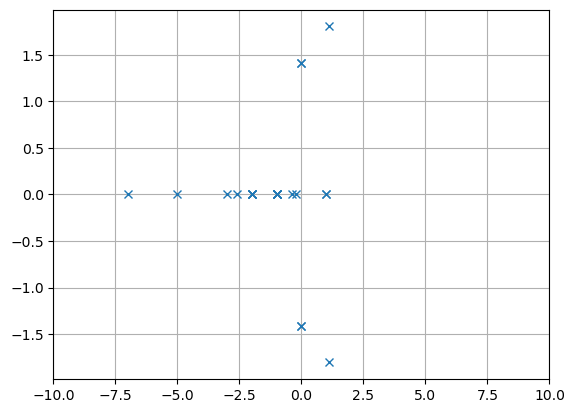

In [30]:
h1 = np.poly1d([1,2,1])
h2 = np.poly1d([1,0,2])
h3 = np.poly1d([1,0,2])
h4 = np.poly1d([1,1])
h5 = np.poly1d([1,1])
h6 = np.poly1d([1,4,4])
h7 = np.poly1d([1,-2,4,1])
h8 = np.poly1d([1,3,1])
h9 = np.poly1d([1,8,15])
h10 = np.poly1d([1,6,-7])
h11 = np.poly1d([1,1])
h12 = np.poly1d([1,-1])
h13 = np.poly1d([1,2])
h14 = np.poly1d([1,2])

#define list of denominators
denominators = [h1,h2,h3,h4,h5,h6,h7,h8,h9,h10,h11,h12,h13,h14]
#for each denominator from list - calculate roots
roots = []
for i in range(len(denominators)):
  roots.extend(np.roots(denominators[i]))

vals, counts = np.unique(roots,return_counts=True)

Real_roots = np.real(roots)
Imag_roots = np.imag(roots)

plt.plot(Real_roots, Imag_roots, 'x')
plt.grid()
plt.xlim(-10,10)
plt.show()





----
## 3. Sprawdź właściwości systemów
-----------------
* na 1. wykresie umieść charakterystyki amplitudowe wszystkich układów
* na 2. wykresie umieść charakterystyki fazowe wszystkich układów
* na 3. wykresie zaznacz połóożenie zer biegonów dla wszystkich układów

Transmitancje układów:
$$H_1(s) = {{s^2+6s+8} \over {s^2+2s+ 3}}$$
$$H_2(s) = {{s^2-2s-8} \over {s^2+2s+ 3}}$$
$$H_3(s) = {{s^2-6s+8} \over {s^2+2s+ 3}}$$
$$H_4(s) = {{s^2+2s-8} \over {s^2+2s+ 3}}$$

Wskaż układ minimalnofazowy



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/tmp/ipykernel_5586/2394406003.py:46: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  figMP.show()
/tmp/ipykernel_5586/2394406003.py:54: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  figZP.show()


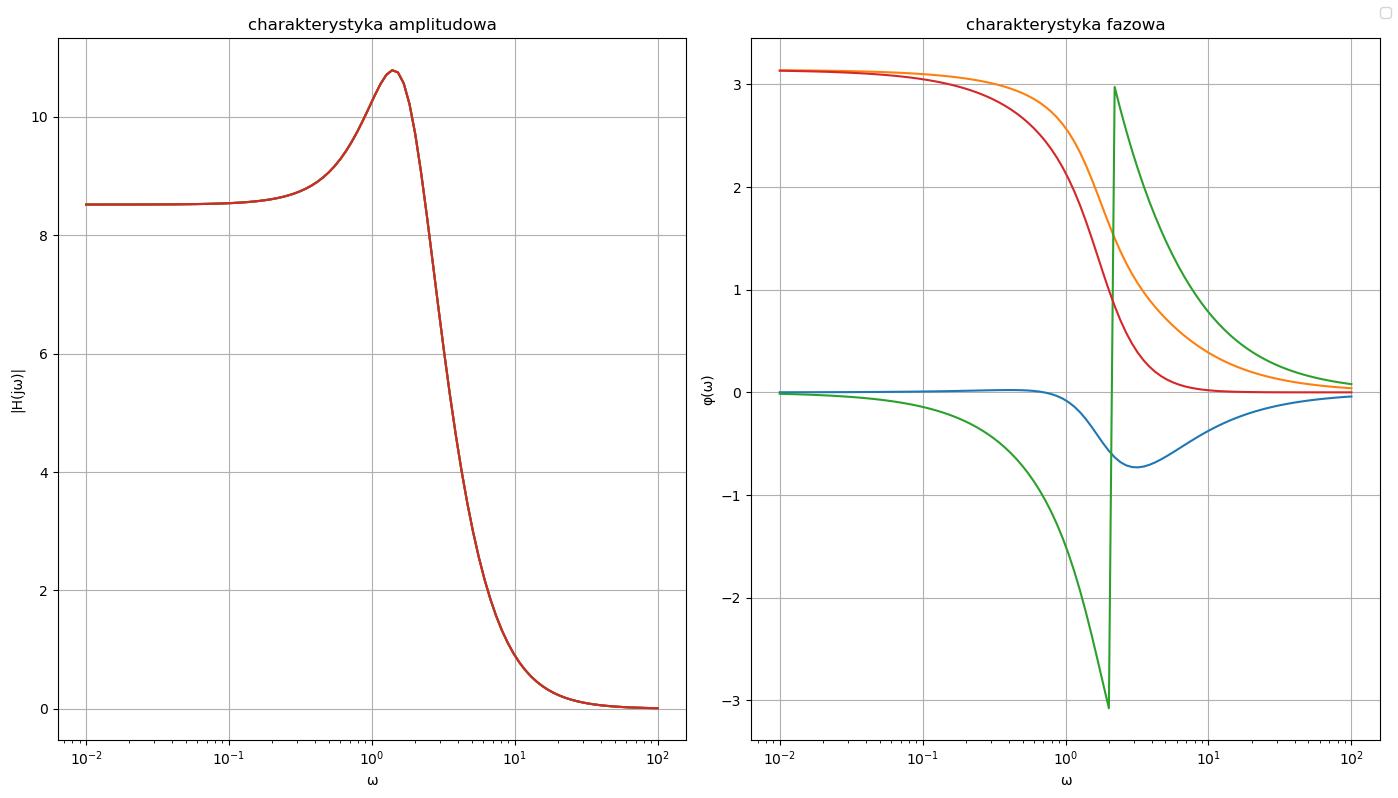

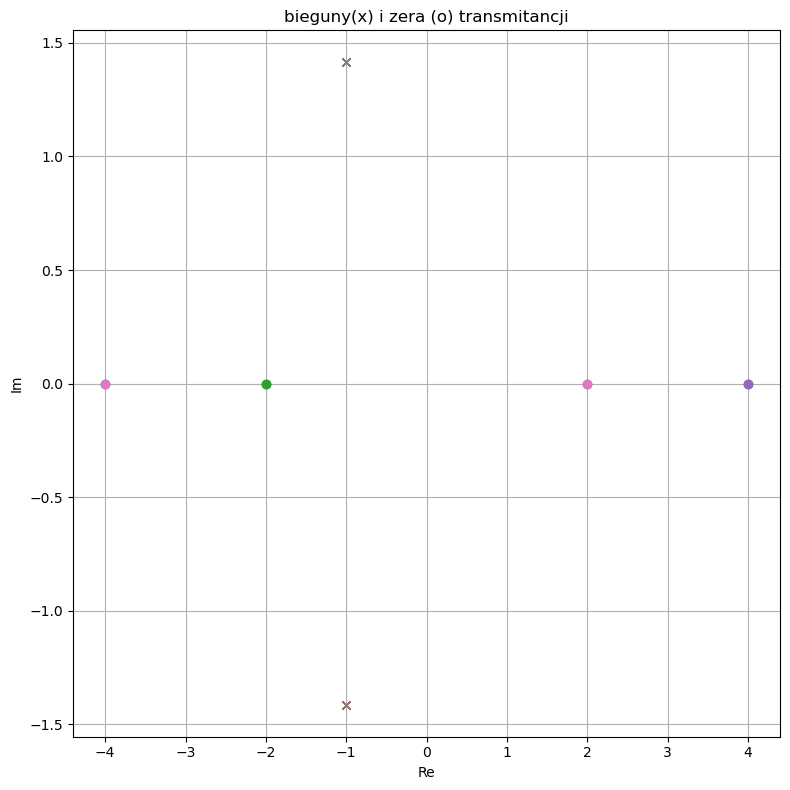

In [52]:
#define list of numerators
numerators = [[1, 6, 8],
              [1,-2,-8],
              [1,-6, 8],
              [1, 2,-8]
]
#define denominator
denominator = [1, 2, 3]




figMP, axsMP = plt.subplots(1, 2, figsize=default_figsize)
figZP, axZP  = plt.subplots(1, 1, figsize=poles_figsize)


for idx, numerator in enumerate(numerators):
  A = np.poly1d(numerator)
  B = np.poly1d(denominator)
  ω_vec = np.logspace(-2,2,100)
  s_vec = 1j * ω_vec
  H_vals = A(s_vec)/B(s_vec)
  #charakterystyka amplitudowa 
  amplitude = np.abs(H_vals)
  axsMP[0].semilogx(ω_vec, 20 * np.log10(amplitude))
  #charakterystyka fazowa
  phase = np.angle(H_vals)
  axsMP[1].semilogx(ω_vec, phase)
  #zera transmitancji
  zera = np.roots(numerator)
  bieguny = np.roots(denominator)
  axZP.plot(np.real(zera), np.imag(zera), 'o')
  axZP.plot(np.real(bieguny), np.imag(bieguny), 'x')


axsMP[0].set_title("charakterystyka amplitudowa")
axsMP[0].set_xlabel("ω")
axsMP[0].set_ylabel("|H(jω)|")
axsMP[0].grid()
axsMP[1].set_title("charakterystyka fazowa")
axsMP[1].set_xlabel("ω")
axsMP[1].set_ylabel("φ(ω)")
axsMP[1].grid()
figMP.legend()
figMP.tight_layout()
figMP.show()


axZP.set_title("bieguny(x) i zera (o) transmitancji")
axZP.set_xlabel("Re")
axZP.set_ylabel("Im") 
axZP.grid()
figZP.tight_layout()
figZP.show()